# Quantification oh helix geometry

This code calculates the helix pitch and the helix radius of a helical trajectory. 
The track is first aligned with the x axis using PCA, to allow for Fourier analysis. The pitch is found by the periodicity of the pattern. The trajectory is then divided into sliding windows that are individually realigned. The mean height of the corresponding bounding boxes is used to estimate the helix radius.

**Input:**

*file_directory*: Path to folder with the helical path file

*file_name*: The name of the csv file with the trajectory coordinates

*px_mm*: The number of pixels equal to 1 mm

*fps*: The frame rate of the timelapse

**Output:**

*helix_measurements.csv*: A csv file with the measured quantities

In [1]:
import csv
import pandas as pd
import os
import numpy as np
from matplotlib import pyplot as plt

from scipy.fft import fft, fftfreq
from sklearn.decomposition import PCA

### Input

In [2]:
### Input and output paths
file_directory = "C:\\Users\\kourkoul\\SCRIPTS\\Paper_scripts\\example_data\\"
file_name  = "helical_path_coordinates.csv"

output_path = file_directory + "results\\" 
if not os.path.exists(output_path):
    os.makedirs(output_path)

### Reading the trajectory file
helical_segment = pd.read_csv(file_directory + file_name)
x                 = helical_segment['x']
y                 = helical_segment['y']
time              = helical_segment['time']

### Pixel size and framerate of timelapse:
px_mm = 67.5  # number of pixels equal to 1 mm
fps = 30

### Segment visualization

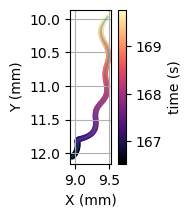

In [3]:
plt.figure(figsize=(2, 2), dpi=100)
plt.plot(x, y, alpha=0.4)
plt.scatter(x, y, c=time, cmap="magma", s=10)
plt.colorbar(label="time (s)")
plt.ylabel("Y (mm)", fontsize=10)
plt.xlabel("X (mm)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().invert_yaxis()
plt.show()

### Alignment with PCA

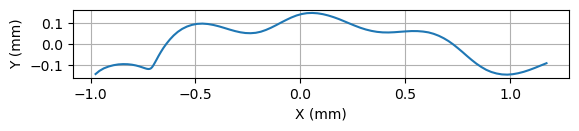

In [4]:
def pca_align(x, y):
    data = np.column_stack((x, y))
    pca = PCA(n_components=2)
    transformed = pca.fit_transform(data)
    x_aligned, y_aligned = transformed[:, 0], transformed[:, 1]
    return x_aligned, y_aligned, pca

x_aligned, y_aligned, pca = pca_align(x, y)

plt.figure()
plt.plot(x_aligned,y_aligned)
plt.ylabel("Y (mm)", fontsize=10)
plt.xlabel("X (mm)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

### Pitch estimation

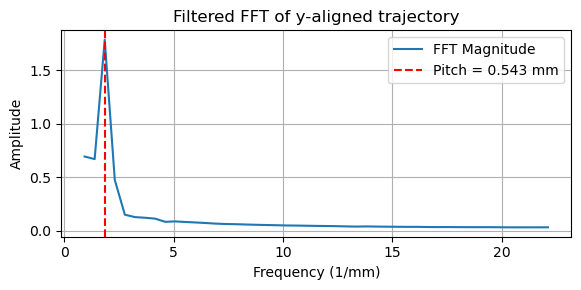

In [5]:
### Note: The parameter `min_freq` is introduced to exclude any peaks at zero frequency from noise.
def estimate_pitch(x_aligned, y_aligned, min_freq, show_plot=True):
    y_centered = y_aligned - np.mean(y_aligned)
    N = len(x_aligned)
    dx = np.mean(np.diff(x_aligned))  # spatial sampling resolution

    # Compute FFT
    freqs = fftfreq(N, dx)
    fft_vals = fft(y_centered)
    fft_magnitude = np.abs(fft_vals)

    # Keep only positive frequencies in a plausible range
    mask = freqs >= min_freq
    positive_freqs = freqs[mask]
    positive_fft = fft_magnitude[mask]

    if len(positive_fft) == 0:
        print("No valid frequencies in selected range.")
        return np.nan
    
    # Find dominant frequency
    dominant_idx = np.argmax(positive_fft)
    dominant_freq = positive_freqs[dominant_idx]
    pitch = 1 / dominant_freq if dominant_freq != 0 else np.nan
    # Plot
    if show_plot:
        plt.figure(figsize=(6, 3))
        plt.plot(positive_freqs, positive_fft, label='FFT Magnitude')
        plt.axvline(dominant_freq, color='red', linestyle='--', label=f'Pitch = {pitch:.3f} mm')
        plt.title("Filtered FFT of y-aligned trajectory")
        plt.xlabel("Frequency (1/mm)")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return pitch

pitch = estimate_pitch(x_aligned, y_aligned, min_freq=0.5, show_plot=True)

### Radius estimation

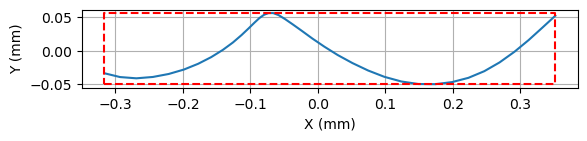

Radius: 0.053


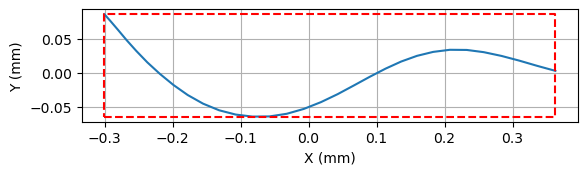

Radius: 0.075


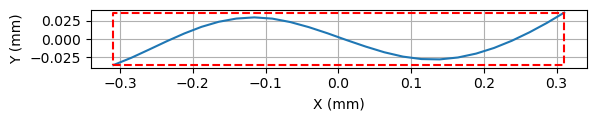

Radius: 0.036


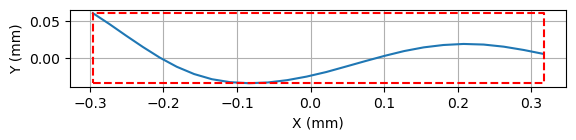

Radius: 0.048


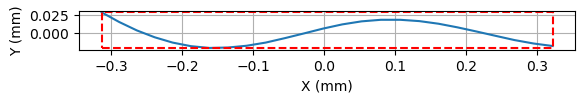

Radius: 0.025


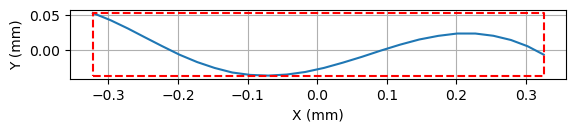

Radius: 0.045


In [6]:
### Finding the helix radius with sliding bounding boxes
def get_pitch_windows(x_aligned, pitch, scale, overlap):
    start = np.min(x_aligned)
    end = np.max(x_aligned)
    step = pitch * (1 - overlap)  
    windows = []
    curr_start = start
    while curr_start + scale*pitch <= end:
        curr_end = curr_start + scale*pitch
        windows.append((curr_start, curr_end))
        curr_start += step
    return windows

windows = get_pitch_windows(x_aligned, pitch, scale=1.2, overlap=0.5)

radius = []
w_id = 0
for w_start, w_end in windows:
    mask = (x_aligned >= w_start) & (x_aligned < w_end)
    xa = x_aligned[mask]
    ya = y_aligned[mask]

    # Re-alignment
    xa_local, ya_local, _ = pca_align(xa, ya)   
    
    # Estimate radius from bounding box in Y
    x_min, x_max = np.min(xa_local), np.max(xa_local)
    y_min, y_max = np.min(ya_local), np.max(ya_local)
    
    radius_local = (y_max - y_min) / 2
    radius.append(radius_local)

    # Plot trajectory
    plt.plot(xa_local, ya_local, label='Trajectory')
    rect_x = [x_min, x_max, x_max, x_min, x_min]
    rect_y = [y_min, y_min, y_max, y_max, y_min]
    plt.plot(rect_x, rect_y, 'r--', label='AABB')
    plt.ylabel("Y (mm)", fontsize=10)
    plt.xlabel("X (mm)", fontsize=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()
    
    w_id += 1

    print(f"Radius: {radius_local:.3f}")

radius_mean = np.mean(radius)
radius_std  = np.std(radius)

### Helix angle

In [7]:
helix_angle = np.degrees(np.arctan(pitch / (2 * np.pi * radius_mean)))

### Saving output

In [8]:
# Define the headers
headers = ["radius_mean", "radius_std", "pitch", "helix_angle (degrees)"]

# Define the row
row = [radius_mean, radius_std, pitch, helix_angle]

# Write to CSV
with open(output_path +"helix_measurements.csv", mode="a", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(headers)
    writer.writerow(row)